# *Image Processing using OpenCV*


##  What is an image?
An image is simply **data made of pixels**.

A **pixel** (*picture element*) is the **smallest unit of an image**.

Think of an image as a **grid (matrix)**:

```text
[ 12  45  78 ]
[ 34  90 120 ]
[ 56  87 255 ]

```

# Types of Images

There are three main types of images used in image processing.

---

## 1. Black and White Image (Binary Image)

A black and white image contains only two possible pixel values:

```text
0         → Black
1 or 255  → White
```

### Characteristics

- Simplest form of image
- Used in thresholding and masking
- Contains only two colors

---

## 2. Grayscale Image

A grayscale image contains different shades of gray.

Pixel values range from:

```text
0    → Black
255  → White
```

Values between `0` and `255` represent different gray intensities.

### Example

```text
0     = Black
127   = Gray
255   = White
```

### Characteristics

- Single-channel image
- Used for edge detection and image analysis
- Requires less computation than color images

---

## 3. Color Image

A color image uses three color channels:

```text
Red
Green
Blue
```

This is known as the **RGB color model**.

However, in OpenCV, images are stored in **BGR** format instead of RGB.

### Pixel Format in OpenCV

```python
[Blue, Green, Red]
```

### Example

```python
[255, 0, 0]
```

This represents **pure blue** in OpenCV.

### Characteristics

- Contains three color channels
- Produces rich and detailed images
- Requires more memory and computation than grayscale images

---

1. **Images are just matrices (arrays) of numbers**
2. **Pixels store intensity or color information**
3. **Color channels (Gray, RGB/BGR)**
4. **Image dimensions and indexing**
5. **Basic OpenCV image operations**
6. **Thresholding and edge detection**
7. **Contours and object detection basics**
8. **Image transformations (resize, crop, rotate)**

Everything else builds on top of these ideas.

**Reading a image**

In [33]:
import cv2
import numpy as np

# Read an image
img = cv2.imread(r"../../Datasets/apple.jpg")
cv2.imshow("apple",img)
cv2.waitKey(0)

-1

# OpenCV Image Fundamentals

### 1. Shape & Dimensions: `(Height, Width, Channels)`
A shape of `(512, 512, 3)` means a 3D matrix representing a **color image**:
* **Height ($y$-axis):** Number of pixel rows (how tall).
* **Width ($x$-axis):** Number of pixel columns (how wide).
* **Channels ($c$):** Values per pixel (3 for color, 1 for grayscale).

### 2. OpenCV Color Space: BGR
OpenCV uses **BGR** order instead of RGB.
* **Format:** `[Blue, Green, Red]`
* **Dominance:** The highest value determines the color (e.g., `[255, 0, 0]` is pure Blue; `[0, 0, 255]` is pure Red).

### 3. Data Type (`dtype`): `uint8`
* **Type:** Unsigned 8-bit integer.
* **Range:** **0 to 255** (`0` = Black / no light, `255` = White / max intensity).

### 4. Coordinate System & Indexing
NumPy matrix indexing `[row, column]` maps to spatial coordinates as **`[y, x]`**.

* **Pixel Slicing:** `image[y, x]`
* **Channel Indexing:** 
  * `image[y, x, 0]` $\rightarrow$ Blue
  * `image[y, x, 1]` $\rightarrow$ Green
  * `image[y, x, 2]` $\rightarrow$ Red

>  NumPy array slicing requires **`[y, x]`**, but built-in OpenCV drawing functions (like `cv2.circle`) expect Cartesian **`(x, y)`**.

In [19]:
print(type(img))


<class 'numpy.ndarray'>


In [20]:
cv2.imshow("apple",img)
cv2.waitKey(0)

-1

**Converting into grayscale**
- RGB into grayscale

In [21]:
img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2.imshow("apple",img_gray)
cv2.waitKey(0)

print(img_gray.shape)

(512, 512)


**playing with RGB color channels**

```PYTHON
img[:, :, 0] = 0  # Turns OFF the Blue channel
img[:, :, 1] = 0  # Turns OFF the Green channel
img[:, :, 2] = 0  # Turns OFF the Red channel
```

In [32]:

img = cv2.imread(r"../../Datasets/apple.jpg")
img[:,:,2]=0


cv2.imshow("apple",img)
cv2.waitKey(0)

-1

### NumPy Image Slicing Cheat Sheet

OpenCV images use a 3-box blueprint: **`img[Rows(y), Columns(x), Channels(c)]`**. 
A colon **`:`** means "everything", **`a:b`** means a range, and a **`single number`** isolates one index.



##### 1. Examples Decoded
*   **`img[:, :, 0] = 0`** 
    *   `:` (all rows) + `:` (all columns) + `0` (Blue channel only).
    *   **Result:** Mutes all Blue light across the entire image.
*   **`img[0, :, :] = 0`** 
    *   `0` (top row only) + `:` (all columns) + `:` (all colors).
    *   **Result:** Draws a 1-pixel-thin black line at the very top edge.

---

##### 2. Quick Slicing Reference

| Code | Visual Target |
| :--- | :--- |
| `img[0:100, :, :]` | Top 100 pixel rows |
| `img[:, :50, :]` | Leftmost 50 pixel columns |
| `img[0:100, 0:100, :]` | $100 \times 100$ pixel square patch in the top-left corner |
| `img[:, :, 2] = 255` | Forces the **Red** channel to maximum intensity everywhere |

In [ ]:
imgBlue=img[:,:,0]
imgGreen=img[:,:,1]
imgRed=img[:,:,2]

new_img=np.hstack((imgBlue,imgGreen,imgRed))
cv2.imshow("BGR",new_img)
cv2.waitKey(0)

27

> `np.hstack()` and `np.vstack()` are used to combine multiple images into a single window, hstack (horizontal stacking) and vstack (vertical stacking).

- Both image have same number of channels, we cannot stack 3- channel color BGR image with 1-channel grayscale image unless converting Grayscale image first. 

**Resize Image**

In [ ]:
img_resize=cv2.resize(img,(256,256))
cv2.imshow("resize",img_resize)
cv2.waitKey(0)
img_resize.shape

(256, 256, 3)

> we can use backend of flask and resize the image for user. for eg: online image resizer

**Flipping the image**

```PYTHON
flipped_image = cv2.flip(src, flipCode)
```
```Text
src: the source image (Numpy array). 
flipcode: determines the flipping direction.
```
 
| flipCode | Flip Direction                          |
| -------- | --------------------------------------- |
| 0        | Flip **vertically** (up ↔ down)         |
| 1        | Flip **horizontally** (left ↔ right)    |
| -1       | Flip **both vertically & horizontally** |


### Importance of Flipping

Flipping is a data augmentation technique used to improve model performance.

1. Increases dataset size
2. Reduces overfitting
3. Improves model generalization
4. Adds variation in image orientation

> Helps the model learn features, not position.
<br>
> Horizontal flipping is most commonly used, while vertical flipping depends on whether it makes sense for the dataset (e.g., not suitable for digits or faces).

In [ ]:
img_flip=cv2.flip(img,1)
cv2.imshow("Flipped Image",img_flip) 
cv2.waitKey(0)

-1

```text
In order to avoid kernel crash, we are using matplotlib 

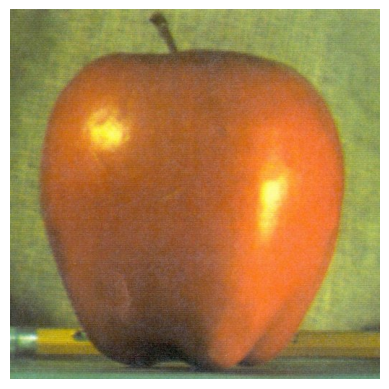

In [34]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(r"../../Datasets/apple.jpg")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


**Cropping an Image**:

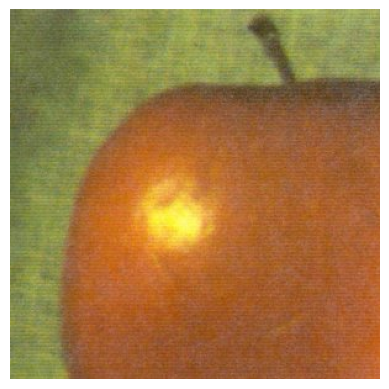

In [ ]:
crop_img=img[0:300,0:300]
crop_img_rgb = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
plt.imshow(crop_img_rgb)
plt.axis("off")
plt.show()

```Text
We convert the image from BGR to RGB because OpenCV stores images in BGR format while Matplotlib displays images in RGB format.
```

| Syntax                  | Meaning                                  |
| ----------------------- | ---------------------------------------- |
| `img[y1:y2, x1:x2]`     | General image crop format                |
| `y1:y2`                 | Select rows (height / vertical area)     |
| `x1:x2`                 | Select columns (width / horizontal area) |
| `img[0:300, 0:300]`     | Crop top-left 300×300 area               |
| `img[100:400, 200:500]` | Crop from y=100→400 and x=200→500        |


| Value     | Meaning                                |
| --------- | -------------------------------------- |
| `100:300` | Start at row 100, end at row 300       |
| `200:500` | Start at column 200, end at column 500 |
| Height    | `300 - 100 = 200 px`                   |
| Width     | `500 - 200 = 300 px`                   |


In [ ]:
# convert back to BGR before saving
crop_img_bgr = cv2.cvtColor(crop_img_rgb, cv2.COLOR_RGB2BGR)
cv2.imwrite("crop_img.png", crop_img_bgr)

True

**Drawing shapes and text**

```text
pt1 = top-left corner
pt2 = bottom-right corner

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


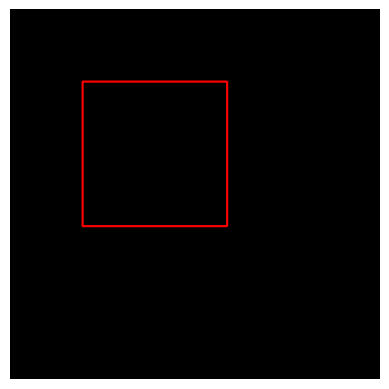

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


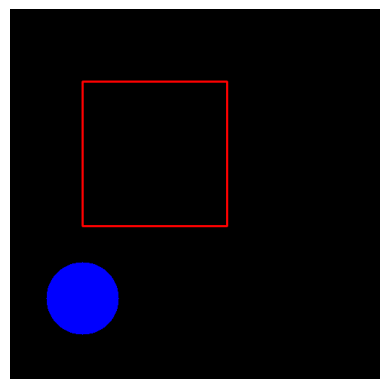

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


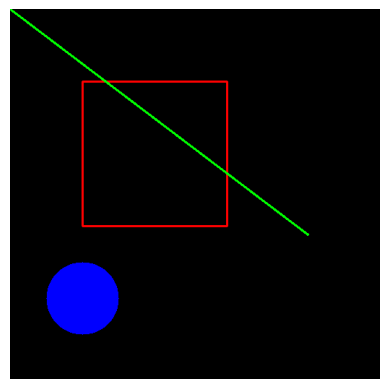

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


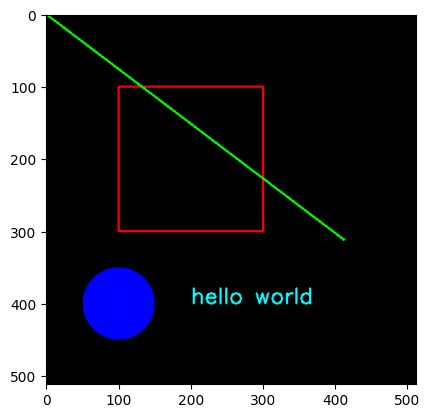

In [35]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

img = cv2.imread(r"../../Datasets/apple.jpg")
img3=img.copy()
img4=np.zeros((512,512,3))

# Rectangle
rec=cv2.rectangle(img4,pt1=(100,100),pt2=(300,300),color=(255,0,0),thickness=2)
plt.imshow(rec)
plt.axis("off")
plt.show()


# Circle
circle=cv2.circle(img4, center=(100,400),radius=50, color=(0,0,255),thickness=-1) # to fill thickness has to be -1. 
plt.imshow(circle)
plt.axis("off")
plt.show()



# Line
lin=cv2.line(img4, pt1=(0,0),pt2=(412,312),thickness=2,color=(0,250,0))
plt.imshow(lin)
plt.axis("off")
plt.show()


# Text
txt=cv2.putText(img4,org=(200,400),fontScale=1,color=(0,255,255),thickness=2, lineType=cv2.LINE_AA,text="hello world",fontFace=cv2.FONT_ITALIC)
plt.imshow(txt)
plt.axis("on")
plt.show()

**working with `openCV` events**

In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img=np.zeros((512,512,3),dtype=np.uint8)
flag=False
ix=-1  #current location of x
iy=-1  # current location of y


def draw(event,x,y,flags,params):

    global flag,ix,iy

    if event==1: #when button is clicked (downpresssed)
        flag=True
        ix=x
        iy=y

#drag
    elif event==0:

        if flag==True:
            cv2.rectangle(img,pt1=(ix,iy),pt2=(x,y),color=(0,255,255),thickness=-1)


    elif event==4:
        flag=False
        cv2.rectangle(img,pt1=(ix,iy),pt2=(x,y),color=(0,255,255),thickness=-1)



cv2.namedWindow(winname="window")
cv2.setMouseCallback("window",draw)



while True:
    cv2.imshow("window",img)

    if cv2.waitKey(1)&0xFF==ord("x"):
        break
cv2.destroyAllWindows()

```Text
Note for not crashing kernel:

Notebook → use matplotlib
Script → use cv2.imshow

**Building a cropping tool**

In [1]:
import cv2
import numpy as np

img = cv2.imread(r"../../Datasets/apple.jpg")
print(img)


flag=False
ix=-1
iy=-1

def crop(event,x,y,flags,params):
    
    global flag,ix,iy

    if event==1:
        flag=True
        ix=x
        iy=y

    elif event==4:
        fx=x
        fy=y
    
        
        flag=False
        cv2.rectangle(img,pt1=(ix,iy),pt2=(x,y),thickness=1,color=(0,0,0))

        cropped=img[iy:fx,ix:fx]
        cv2.imshow("new_window",cropped)
        cv2.waitKey(0)



cv2.namedWindow(winname="window")
cv2.setMouseCallback("window",crop)


while True:
    cv2.imshow("window",img)

    if cv2.waitKey(1) & 0xFF==ord("x"):
        break 


cv2.destroyAllWindows()


[[[ 91 126 122]
  [ 82 119 115]
  [ 87 124 120]
  ...
  [103 168 153]
  [103 168 153]
  [105 170 155]]

 [[ 87 122 118]
  [ 77 114 110]
  [ 80 117 113]
  ...
  [114 181 166]
  [116 183 168]
  [118 185 170]]

 [[ 82 117 113]
  [ 74 111 107]
  [ 78 115 111]
  ...
  [108 178 161]
  [109 180 163]
  [111 182 165]]

 ...

 [[113 157 116]
  [115 160 117]
  [120 163 120]
  ...
  [109 139  98]
  [109 141 100]
  [111 144 100]]

 [[107 151 112]
  [109 153 112]
  [112 155 112]
  ...
  [112 143  98]
  [111 144  99]
  [111 144  99]]

 [[113 157 118]
  [113 157 116]
  [117 157 116]
  ...
  [125 156 111]
  [120 154 107]
  [118 152 105]]]


**working with video**

In [2]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

fourcc = cv2.VideoWriter_fourcc(*"XVID")
out = cv2.VideoWriter("output.avi", fourcc, 20.0, (640, 480))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # convert back to BGR for saving
    gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    out.write(gray_bgr)

    cv2.imshow("webcam", gray)

    if cv2.waitKey(1) & 0xFF == ord("x"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

**How to play video**

In [3]:
import cv2
import time

cap=cv2.VideoCapture("output.avi")

while True:

    ret, frame=cap.read()


    time.sleep(1/20)  #frame rate was set to 20 while capturing video
    cv2.imshow("webcam",frame)

    if cv2.waitKey(1) & 0xFF==ord("x"):
        break

cap.release()
cv2.destroyAllWindows()